In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
ruta_dataset = '/content/drive/MyDrive/Colab Notebooks/machine learning/datasets/new.csv'
df = pd.read_csv(ruta_dataset, encoding='latin1', low_memory=False)
col_del = ['url', 'id', 'Cid', 'tradeTime', 'DOM']
df_limpio = df.drop(col_del, axis=1)
df_limpio = df_limpio.dropna()

df_limpio = df_limpio.sample(n=25000, random_state=43)

In [18]:
col_texto = df_limpio.select_dtypes(include=['object']).columns
df_procesado = pd.get_dummies(df_limpio, columns=col_texto, drop_first=True)
df_procesado = df_procesado.astype(float)

In [19]:
y = df_procesado['totalPrice'].values
X_dataframe = df_procesado.drop('totalPrice', axis=1)
X_matriz = X_dataframe.values

In [20]:
def featureNormalize(X):
  X_norm = X.copy()
  mu = np.mean(X, axis=0)
  sigma = np.std(X, axis=0)

  sigma[sigma == 0] = 1e-8
  X_norm = (X - mu) / sigma

  return X_norm, mu, sigma


**Descenso por el Gradiente**

In [21]:
def computeCostMulti(X, y, theta):
  m= y.shape[0]
  J = (1/(2 * m)) * np.sum(np.square(X.dot(theta) - y))
  return J

In [22]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):
  m = y.shape[0]
  theta = theta.copy()
  J_history = []
  for i in range(num_iters):
    theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
    J_history.append(computeCostMulti(X, y, theta))
  return theta, J_history

In [23]:
X_norm, mu, sigma = featureNormalize(X_matriz)

m = len(y)
X_ready = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

print(f"Cantidad de ejemplos (m): {m}")
print(f"Cantidad de características (n + 1 sesgo): {X_ready.shape[1]}")

Cantidad de ejemplos (m): 25000
Cantidad de características (n + 1 sesgo): 277


Costo final Alcanzado: 3145.22


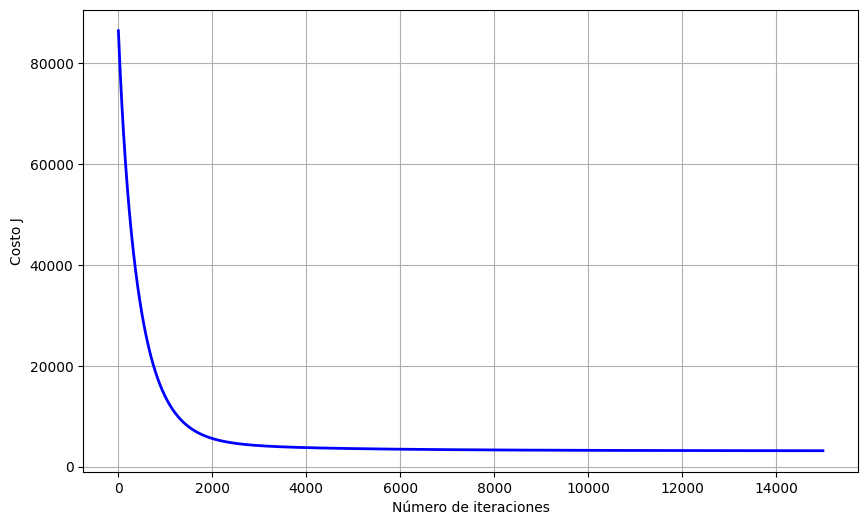

In [24]:
theta_inicial = np.zeros(X_ready.shape[1])
alpha = 0.001
num_iters = 15000

theta, J_history = gradientDescentMulti(X_ready, y, theta_inicial, alpha, num_iters)
print('Costo final Alcanzado: {:.2f}'.format(J_history[-1]))

plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(J_history)), J_history, lw=2, color='blue')
plt.xlabel('Número de iteraciones')
plt.ylabel('Costo J')
plt.grid(True)
plt.show()


In [25]:
casa_prueba = X_matriz[0].copy()

casa_prueba_norm = (casa_prueba - mu) / sigma

X_array = np.concatenate([[1], casa_prueba_norm])

In [26]:
price = np.dot(X_array, theta)

print('El precio predecido para la primera casa del dataset: ${:.0f}'.format(price))

El precio predecido para la primera casa del dataset: $274


## **Ecuación de la Normal**

In [27]:
def normalEqn(X, y):
    theta = np.zeros(X.shape[1])

    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T, X)), X.T), y)
    return theta

In [28]:
m = len(y)

X_normal = np.concatenate([np.ones((m, 1)), X_matriz], axis=1)

theta_normal = normalEqn(X_normal, y)
print('Theta calculado a partir de la ecuación de la normal: {:s}'.format(str(theta_normal)))

X_array_normal = np.concatenate([[1], X_matriz[0].copy()])

price_normal = np.dot(X_array_normal, theta_normal)

print('Precio predecido para la primera casa del dataset: ${:.0f}'.format(price_normal))

Theta calculado a partir de la ecuación de la normal: [ 1.24716162e+03 -5.24721855e+00 -2.34535910e+01 -6.70690818e-03
  7.47793745e-03  4.28651074e+00  1.91989175e+01  2.98470498e+00
  2.72341609e+00  5.82961373e+00  3.60719435e+01  1.43633108e+01
  2.94819203e+00  5.40530233e-02 -3.73759079e-01  4.76168963e-04
 -1.15495317e+02 -1.08128333e+02 -1.12817583e+02 -1.15305062e+02
 -2.63651860e+02 -3.24542119e+02 -3.87805988e+00 -1.41194621e+01
 -5.01472266e+01  1.72267651e+01 -2.74569573e+01 -3.47428314e+01
  3.53866408e+01  1.77825872e+02  6.20222816e+01  4.46782179e+00
  7.76444468e+00 -6.13739704e-01  1.52272033e+01  9.84266470e-01
 -7.05134827e+00  1.13405214e+01  7.51828462e+00  9.39950492e+00
 -1.87363939e+00  1.79451108e+01  2.22111257e+01  1.37873356e+01
  1.41559515e+01  2.41266420e+01  1.29250416e+01  1.32869355e+01
  1.62228503e+01  1.26110601e+01  6.46154608e-01  1.78362908e+01
  6.16572982e+01 -2.53908503e+01  4.36156160e+01  2.34982596e+01
 -4.93944180e+00  1.85111173e+02  2.